In [2]:
# Instalación
# pip install seaborn

# Importación (convención estándar)
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

### Configuración inicial

In [3]:
# Establecer estilo
sns.set_theme()  # Estilo por defecto de Seaborn

# Estilos disponibles
sns.set_style("whitegrid")   # Fondo blanco con grid
sns.set_style("darkgrid")    # Fondo gris con grid
sns.set_style("white")       # Fondo blanco sin grid
sns.set_style("dark")        # Fondo gris sin grid
sns.set_style("ticks")       # Ejes con marcas

# Contexto (escala de elementos)
sns.set_context("paper")     # Más pequeño
sns.set_context("notebook")  # Por defecto
sns.set_context("talk")      # Para presentaciones
sns.set_context("poster")    # Más grande

# Paleta de colores
sns.set_palette("deep")      # Por defecto
sns.set_palette("pastel")
sns.set_palette("Set2")
sns.set_palette("husl")

# Configuración completa
sns.set_theme(style="whitegrid", palette="deep", context="notebook")

### Datasets de ejemplo de Seaborn

In [4]:
# Ver datasets disponibles
print(sns.get_dataset_names())

# Cargar datasets
tips = sns.load_dataset("tips")       # Propinas en restaurante
iris = sns.load_dataset("iris")       # Flores iris
titanic = sns.load_dataset("titanic") # Pasajeros del Titanic
penguins = sns.load_dataset("penguins")  # Pingüinos
flights = sns.load_dataset("flights")    # Vuelos mensuales

print(tips.head())

['anagrams', 'anscombe', 'attention', 'brain_networks', 'car_crashes', 'diamonds', 'dots', 'dowjones', 'exercise', 'flights', 'fmri', 'geyser', 'glue', 'healthexp', 'iris', 'mpg', 'penguins', 'planets', 'seaice', 'taxis', 'tips', 'titanic']
   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4


Histogramas

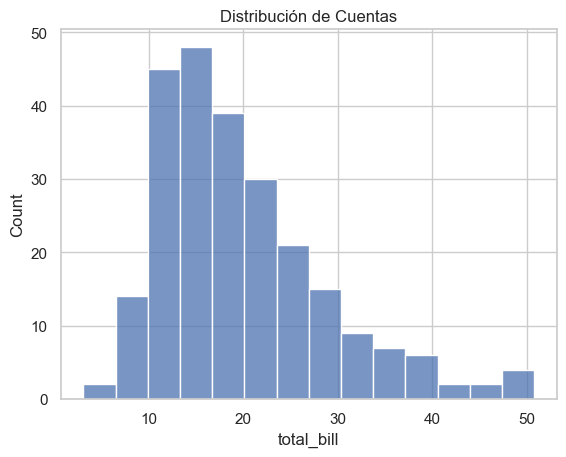

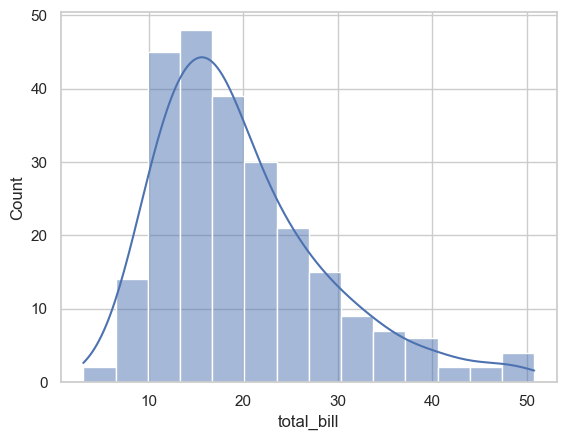

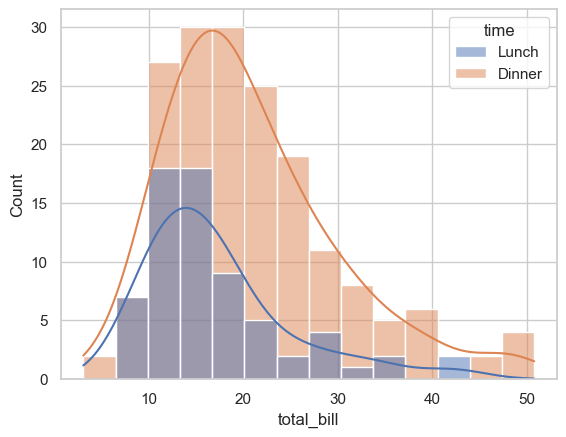

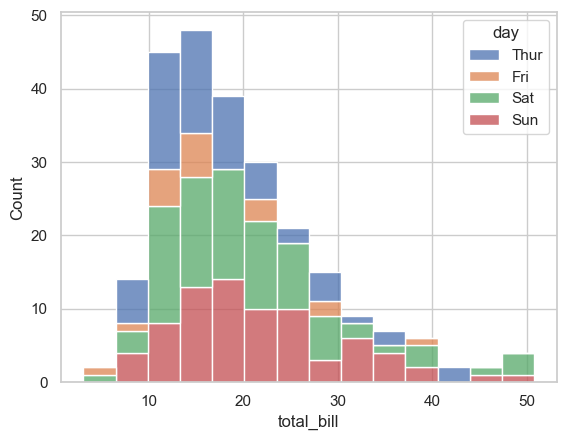

In [5]:
# Histograma básico
sns.histplot(data=tips, x="total_bill")
plt.title("Distribución de Cuentas")
plt.show()

# Con KDE (densidad)
sns.histplot(data=tips, x="total_bill", kde=True)
plt.show()

# Por categoría
sns.histplot(data=tips, x="total_bill", hue="time", kde=True)
plt.show()

# Múltiples histogramas
sns.histplot(data=tips, x="total_bill", hue="day", multiple="stack")
plt.show()

In [6]:
iris = sns.load_dataset("iris")
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


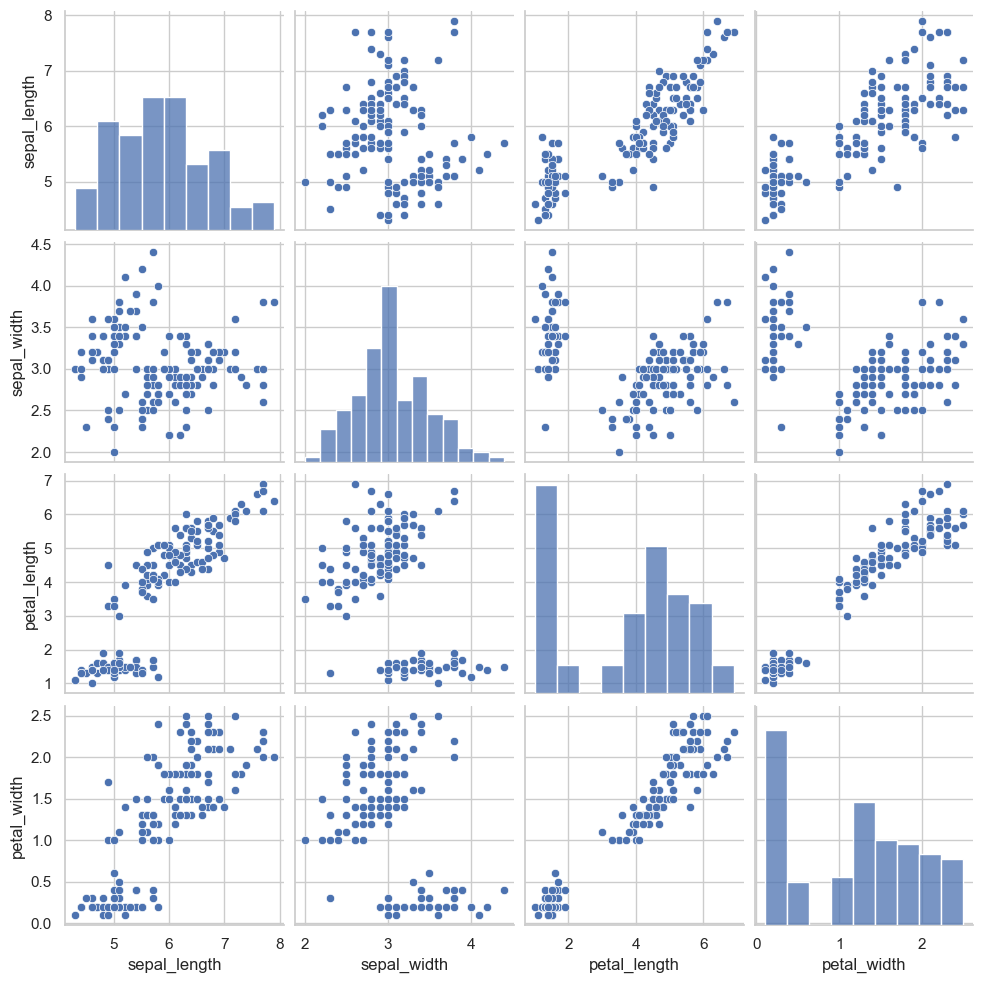

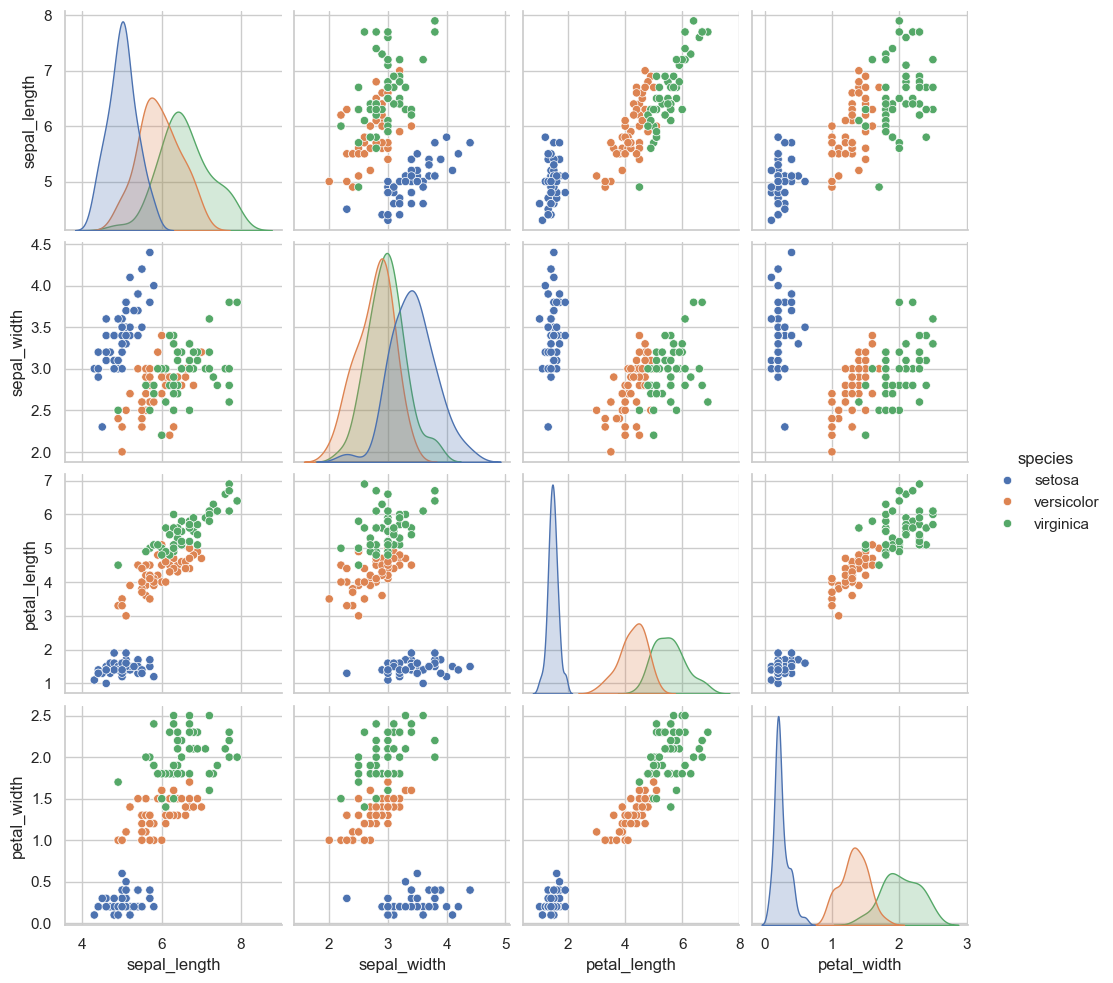

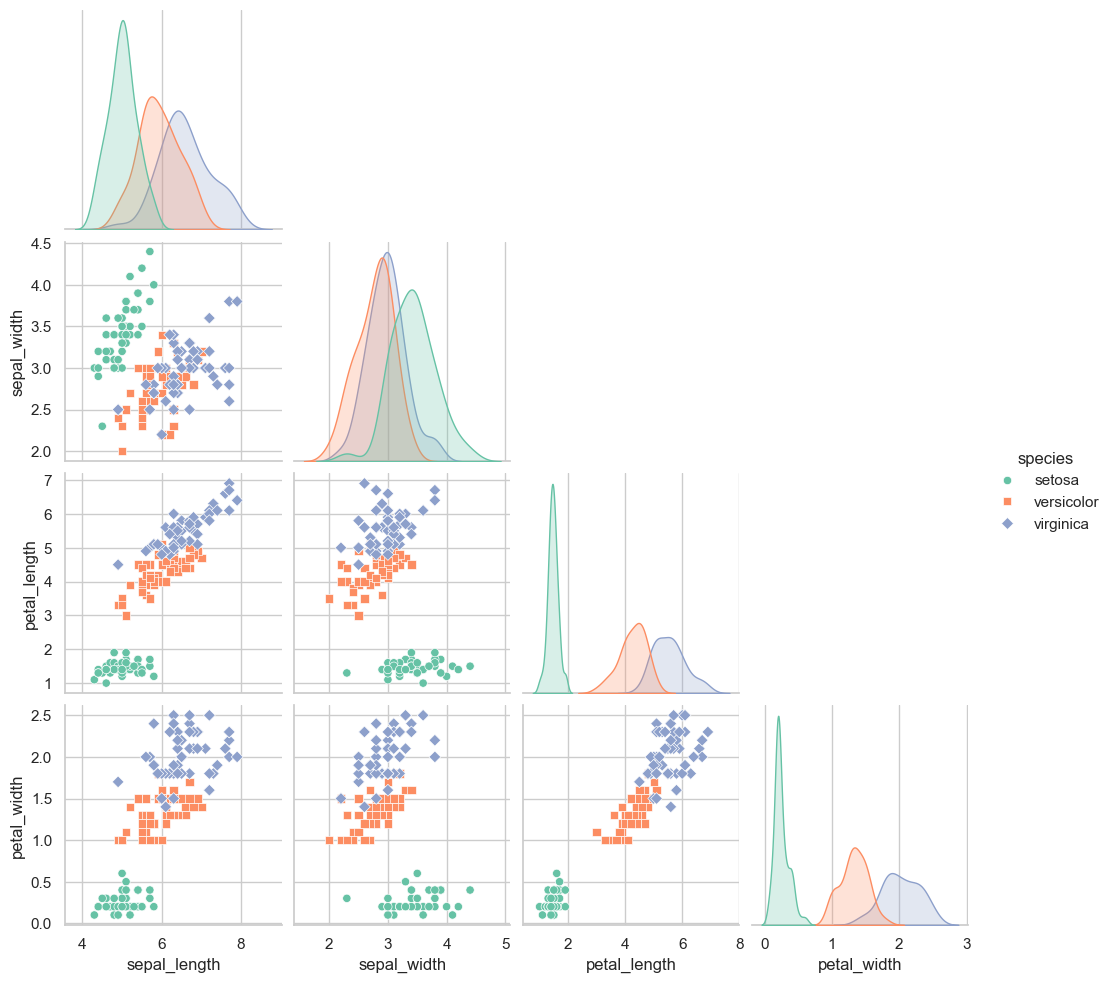

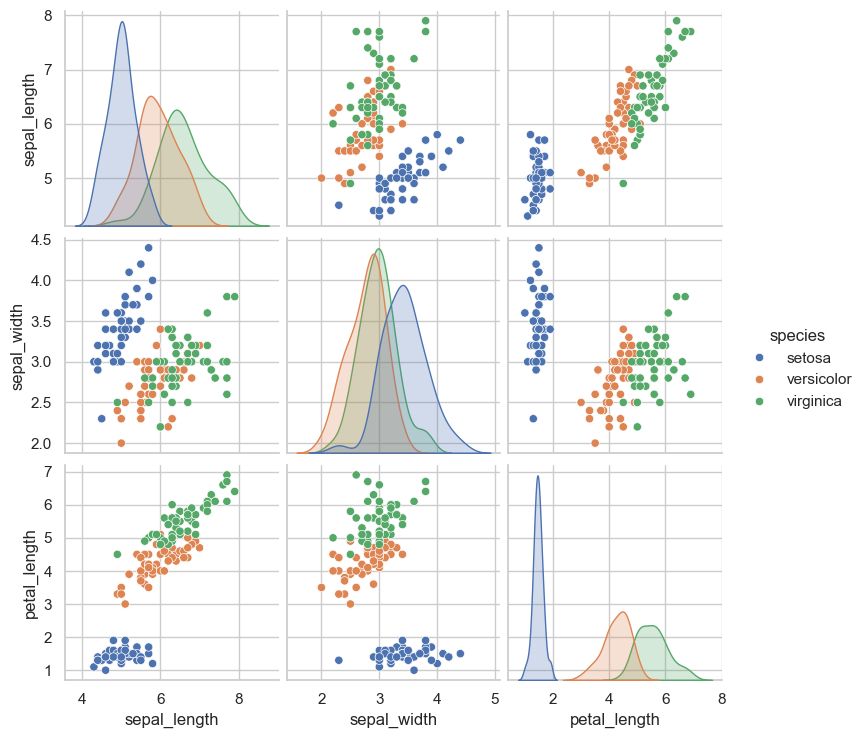

In [7]:


# Básico
sns.pairplot(iris)
plt.show()

# Por especies
sns.pairplot(iris, hue="species")
plt.show()

# Personalizado
sns.pairplot(iris, hue="species",
             diag_kind="kde",      # En diagonal: 'hist' o 'kde'
             markers=["o", "s", "D"],
             palette="Set2",
             corner=True)          # Solo triángulo inferior
plt.show()

# Seleccionar variables
sns.pairplot(iris, vars=["sepal_length", "sepal_width", "petal_length"],
             hue="species")
plt.show()

# Ejemplo Completo

C:\Users\Fran\AppData\Local\Temp\ipykernel_39812\2470425662.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=tips, x="day", y="total_bill", palette="Set2", ax=ax3)


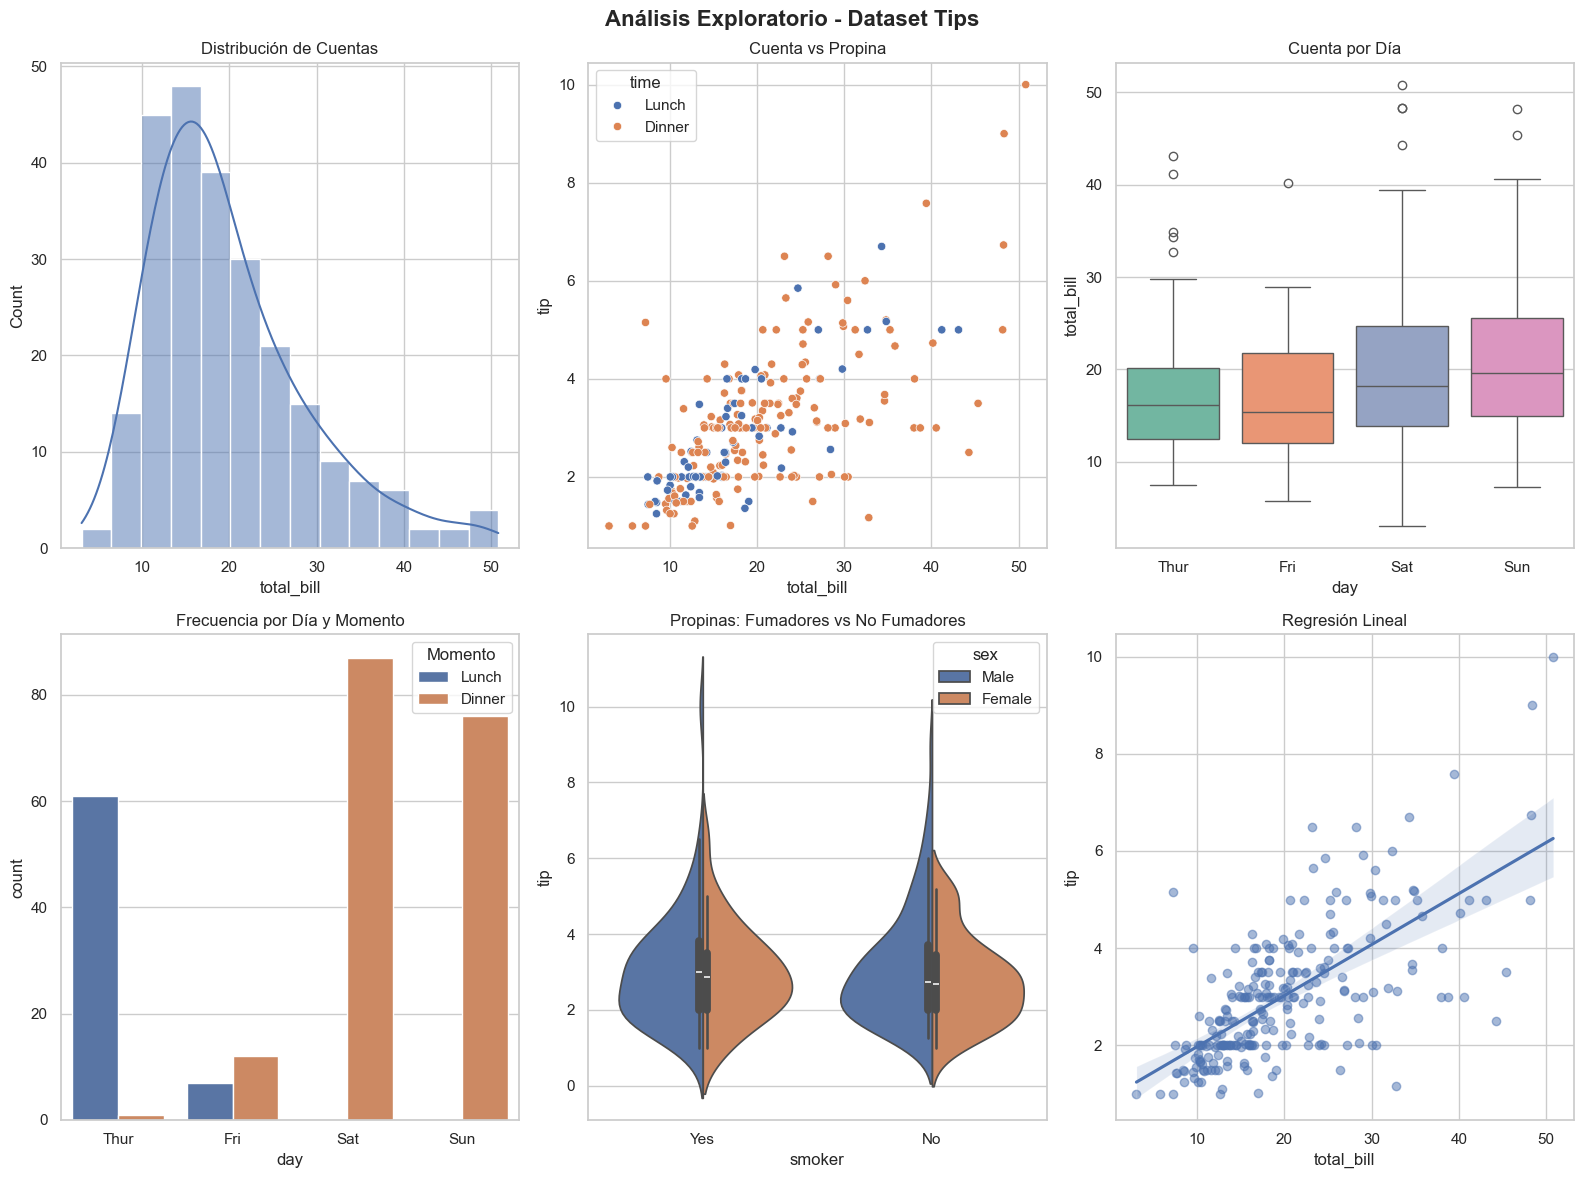

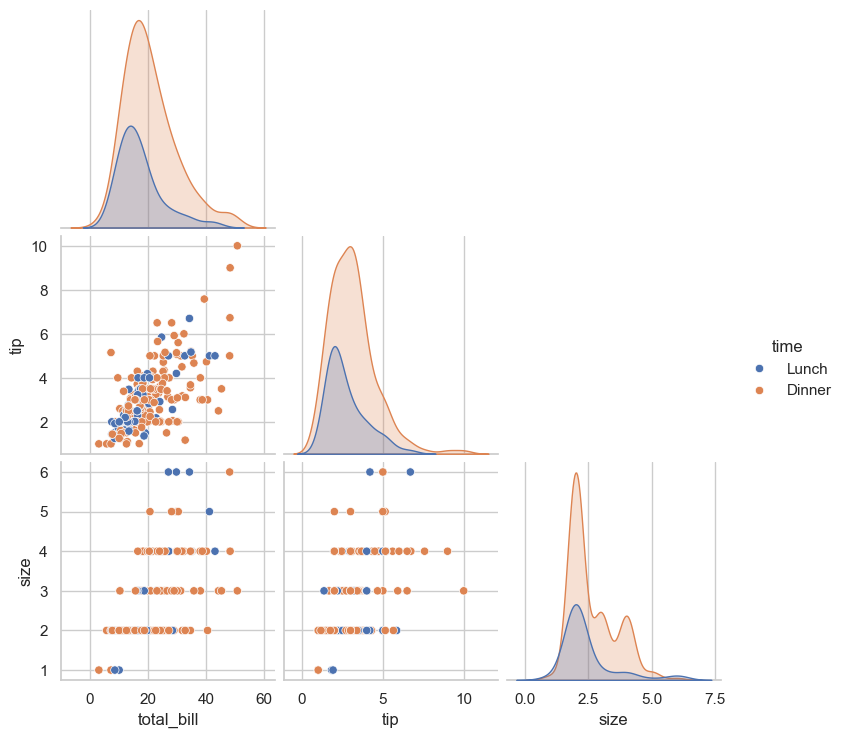

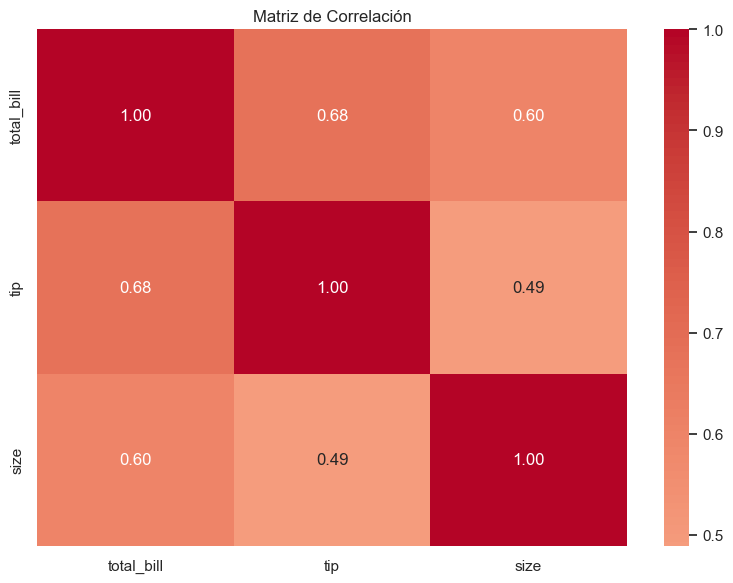

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Cargar datos
tips = sns.load_dataset("tips")

# Configurar estilo
sns.set_theme(style="whitegrid", palette="deep")

# Crear figura con múltiples gráficos
fig = plt.figure(figsize=(16, 12))
fig.suptitle("Análisis Exploratorio - Dataset Tips", fontsize=16, fontweight="bold")

# 1. Distribución de cuentas
ax1 = fig.add_subplot(2, 3, 1)
sns.histplot(data=tips, x="total_bill", kde=True, ax=ax1)
ax1.set_title("Distribución de Cuentas")

# 2. Relación cuenta-propina
ax2 = fig.add_subplot(2, 3, 2)
sns.scatterplot(data=tips, x="total_bill", y="tip", hue="time", ax=ax2)
ax2.set_title("Cuenta vs Propina")

# 3. Box plot por día
ax3 = fig.add_subplot(2, 3, 3)
sns.boxplot(data=tips, x="day", y="total_bill", palette="Set2", ax=ax3)
ax3.set_title("Cuenta por Día")

# 4. Conteo por día y momento
ax4 = fig.add_subplot(2, 3, 4)
sns.countplot(data=tips, x="day", hue="time", ax=ax4)
ax4.set_title("Frecuencia por Día y Momento")
ax4.legend(title="Momento")

# 5. Violin plot fumadores
ax5 = fig.add_subplot(2, 3, 5)
sns.violinplot(data=tips, x="smoker", y="tip", hue="sex", split=True, ax=ax5)
ax5.set_title("Propinas: Fumadores vs No Fumadores")

# 6. Regresión
ax6 = fig.add_subplot(2, 3, 6)
sns.regplot(data=tips, x="total_bill", y="tip", ax=ax6, scatter_kws={"alpha": 0.5})
ax6.set_title("Regresión Lineal")

plt.tight_layout()
plt.savefig("analisis_tips.png", dpi=150, bbox_inches="tight")
plt.show()

# Pair plot separado
sns.pairplot(tips, hue="time", diag_kind="kde", corner=True)
plt.savefig("pairplot_tips.png", dpi=150)
plt.show()

# Heatmap de correlación
plt.figure(figsize=(8, 6))
numeric_tips = tips.select_dtypes(include=[np.number])
sns.heatmap(numeric_tips.corr(), annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Matriz de Correlación")
plt.tight_layout()
plt.savefig("correlacion_tips.png", dpi=150)
plt.show()